In [ ]:
import json
import random
import zipfile
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

SEED = 42


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Random seed:", SEED)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch version: 2.11.0+cu128
Random seed: 42
Device: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
ROOT = Path("/content/drive/MyDrive/ADS2002")
SPLIT_DIR = ROOT / "splits(FINAL)"
ZIP_PATH = ROOT / "sample_images.zip"
OUTPUT_DIR = ROOT / "efficientnet_outputs"

# Extracting to Colab's local disk is usually faster than reading every
# image directly from Google Drive during training.
LOCAL_IMAGE_DIR = Path("/content/data/melanoma_images")

TRAIN_CSV = SPLIT_DIR / "train_labels.csv"
VAL_CSV = SPLIT_DIR / "val_labels.csv"
TEST_CSV = SPLIT_DIR / "test_labels.csv"
CHECKPOINT_PATH = OUTPUT_DIR / "best_efficientnet_b0.pt"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
LOCAL_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

required_files = [TRAIN_CSV, VAL_CSV, TEST_CSV, ZIP_PATH]
for path in required_files:
    print(f"{path}: {path.exists()}")
    assert path.exists(), f"Missing file: {path}"


/content/drive/MyDrive/ADS2002/splits(FINAL)/train_labels.csv: True
/content/drive/MyDrive/ADS2002/splits(FINAL)/val_labels.csv: True
/content/drive/MyDrive/ADS2002/splits(FINAL)/test_labels.csv: True
/content/drive/MyDrive/ADS2002/sample_images.zip: True


# Dataset split summary

In [ ]:
train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

splits = {
    "train": train_df,
    "validation": val_df,
    "test": test_df,
}

required_columns = {"image_name", "patient_id", "target"}
summary_rows = []

for split_name, df in splits.items():
    missing_columns = required_columns - set(df.columns)
    assert not missing_columns, (
        f"{split_name} is missing columns: {sorted(missing_columns)}"
    )
    assert df["image_name"].notna().all()
    assert df["patient_id"].notna().all()
    assert not df["image_name"].duplicated().any()
    assert set(df["target"].dropna().unique()).issubset({0, 1})

    n_positive = int(df["target"].sum())
    summary_rows.append({
        "split": split_name,
        "images": len(df),
        "patients": df["patient_id"].nunique(),
        "benign": len(df) - n_positive,
        "melanoma": n_positive,
        "melanoma_rate": n_positive / len(df),
    })

split_summary = pd.DataFrame(summary_rows)
display(split_summary.style.format({"melanoma_rate": "{:.2%}"}))


,split,images,patients,benign,melanoma,melanoma_rate
0,train,5598,337,5499,99,1.77%
1,validation,1266,85,1237,29,2.29%
2,test,1988,106,1957,31,1.56%


# Patient-leakage validation

In [ ]:
for (name_a, df_a), (name_b, df_b) in combinations(splits.items(), 2):
    patient_overlap = set(df_a["patient_id"]) & set(df_b["patient_id"])
    image_overlap = set(df_a["image_name"]) & set(df_b["image_name"])

    print(
        f"{name_a} vs {name_b}: "
        f"patient overlap={len(patient_overlap)}, "
        f"image overlap={len(image_overlap)}"
    )

    assert not patient_overlap, "Patient leakage detected"
    assert not image_overlap, "Image leakage detected"

all_labels = pd.concat(splits.values(), ignore_index=True)
assert all_labels["image_name"].is_unique
print("Leakage checks passed.")


train vs validation: patient overlap=0, image overlap=0
train vs test: patient overlap=0, image overlap=0
validation vs test: patient overlap=0, image overlap=0
Leakage checks passed.


# Extract and validate images

In [ ]:
image_extensions = {".jpg", ".jpeg", ".png"}


def find_images(folder):
    return [
        path for path in folder.rglob("*")
        if path.is_file() and path.suffix.lower() in image_extensions
    ]


image_files = find_images(LOCAL_IMAGE_DIR)
expected_image_count = all_labels["image_name"].nunique()

if len(image_files) < expected_image_count:
    print("Extracting image ZIP to Colab local storage...")
    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(LOCAL_IMAGE_DIR)
    image_files = find_images(LOCAL_IMAGE_DIR)

image_ids = [path.stem for path in image_files]
duplicate_ids = pd.Series(image_ids).duplicated().sum()
assert duplicate_ids == 0, "Duplicate image filenames were found"

IMAGE_LOOKUP = {path.stem: path for path in image_files}
missing_images = set(all_labels["image_name"]) - set(IMAGE_LOOKUP)

print("Image files found:", len(image_files))
print("Missing labelled images:", len(missing_images))
assert not missing_images, f"Missing image IDs include: {list(missing_images)[:5]}"


Extracting image ZIP to Colab local storage...
Image files found: 8852
Missing labelled images: 0


# Explore the class imbalance

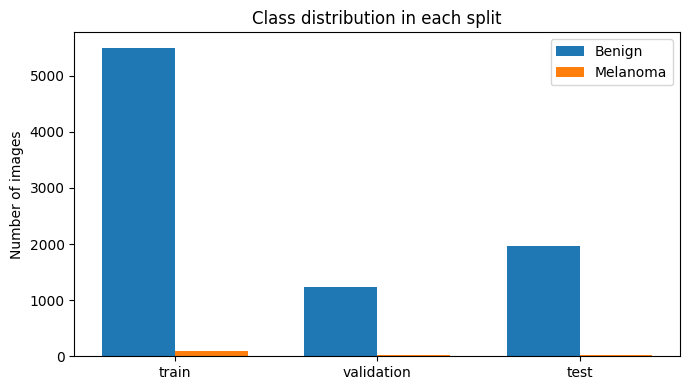

In [ ]:
fig, axis = plt.subplots(figsize=(7, 4))
x = np.arange(len(split_summary))
width = 0.36

axis.bar(x - width / 2, split_summary["benign"], width, label="Benign")
axis.bar(x + width / 2, split_summary["melanoma"], width, label="Melanoma")
axis.set_xticks(x, split_summary["split"])
axis.set_ylabel("Number of images")
axis.set_title("Class distribution in each split")
axis.legend()
plt.tight_layout()
plt.show()


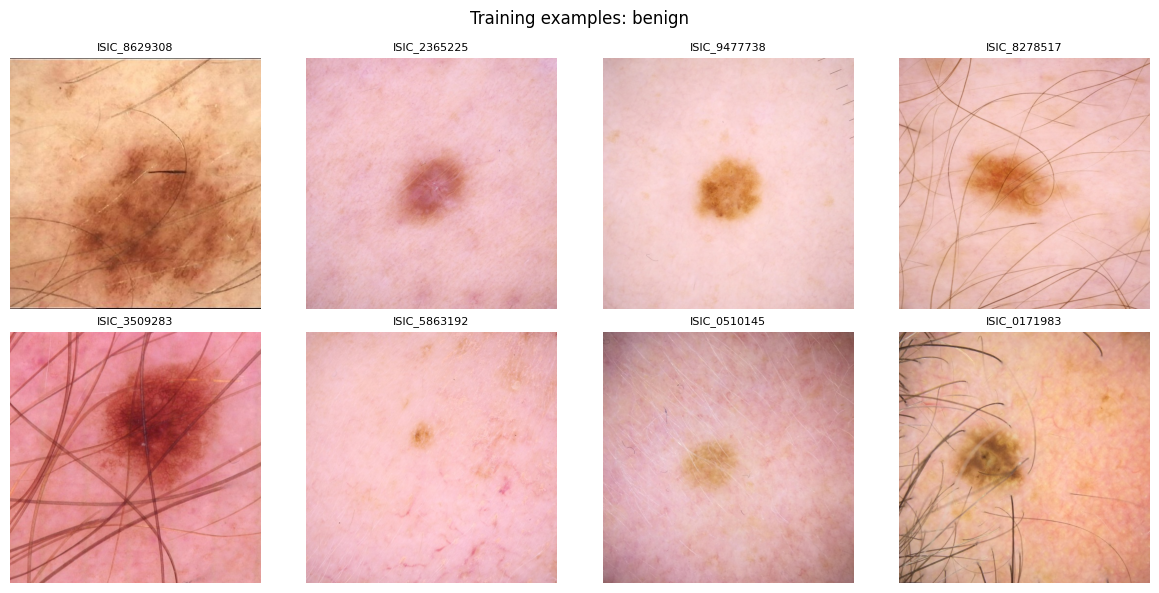

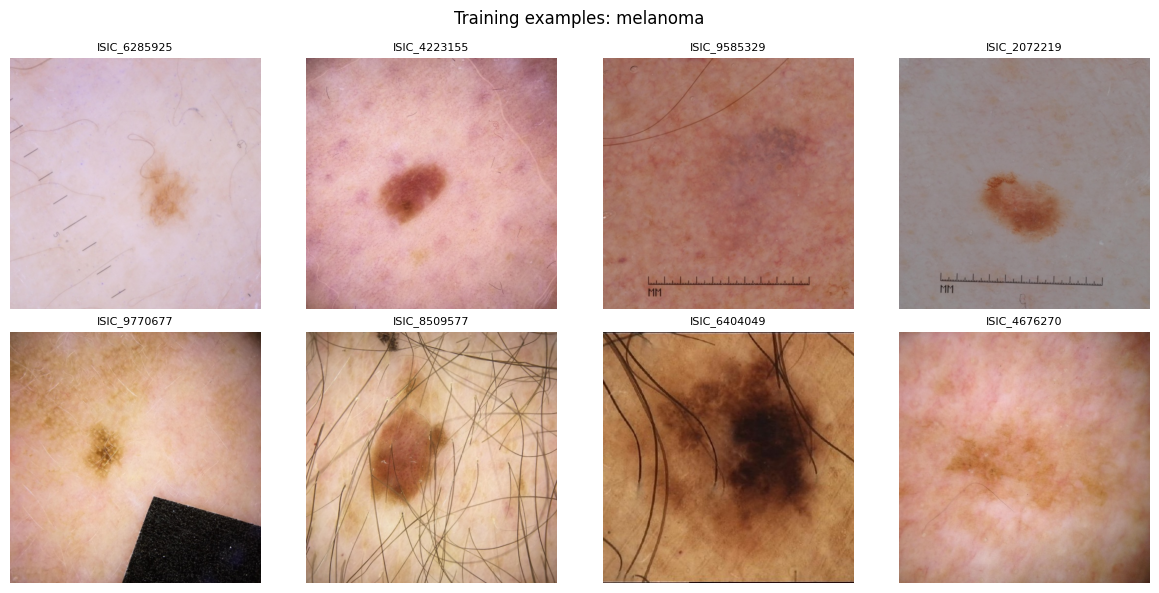

In [ ]:
def show_examples(df, target, n=8, title=""):
    subset = df.loc[df["target"] == target]
    sample = subset.sample(n=min(n, len(subset)), random_state=SEED)
    columns = 4
    rows = int(np.ceil(len(sample) / columns))
    fig, axes = plt.subplots(rows, columns, figsize=(12, 3 * rows))
    axes = np.atleast_1d(axes).ravel()

    for axis, (_, row) in zip(axes, sample.iterrows()):
        with Image.open(IMAGE_LOOKUP[row["image_name"]]) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(row["image_name"], fontsize=8)
        axis.axis("off")

    for axis in axes[len(sample):]:
        axis.axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_examples(train_df, target=0, title="Training examples: benign")
show_examples(train_df, target=1, title="Training examples: melanoma")


In [ ]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05,
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.9, 1.1),
    ),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

evaluation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class MelanomaDataset(Dataset):
    def __init__(self, dataframe, image_lookup, transform):
        self.dataframe = dataframe.reset_index(drop=True).copy()
        self.image_lookup = image_lookup
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        row = self.dataframe.iloc[index]
        image_path = self.image_lookup[row["image_name"]]

        with Image.open(image_path) as image:
            image = image.convert("RGB")
            image_tensor = self.transform(image)

        target = torch.tensor(row["target"], dtype=torch.float32)
        return image_tensor, target


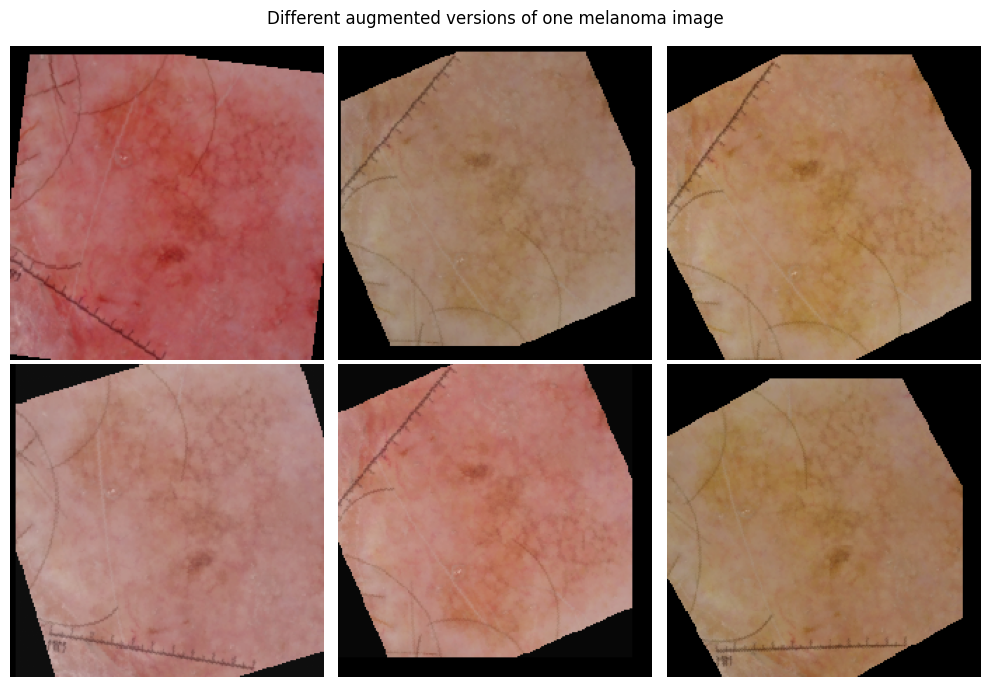

In [ ]:
def denormalise(image_tensor):
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (image_tensor.cpu() * std + mean).clamp(0, 1)


melanoma_row = train_df.loc[train_df["target"] == 1].iloc[0]
with Image.open(IMAGE_LOOKUP[melanoma_row["image_name"]]) as source_image:
    source_image = source_image.convert("RGB")
    augmented_images = [train_transform(source_image) for _ in range(6)]

fig, axes = plt.subplots(2, 3, figsize=(10, 7))
for axis, image_tensor in zip(axes.ravel(), augmented_images):
    axis.imshow(denormalise(image_tensor).permute(1, 2, 0))
    axis.axis("off")
fig.suptitle("Different augmented versions of one melanoma image")
plt.tight_layout()
plt.show()


In [ ]:
BATCH_SIZE = 32
loader_generator = torch.Generator().manual_seed(SEED)

train_dataset = MelanomaDataset(train_df, IMAGE_LOOKUP, train_transform)
val_dataset = MelanomaDataset(val_df, IMAGE_LOOKUP, evaluation_transform)
test_dataset = MelanomaDataset(test_df, IMAGE_LOOKUP, evaluation_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

batch_images, batch_targets = next(iter(train_loader))
print("Image batch shape:", batch_images.shape)
print("Target batch shape:", batch_targets.shape)
print("Melanomas in this batch:", int(batch_targets.sum()))

# The preview above advances the random states. Reset them so training
# still begins from the agreed seed and shuffled order.
set_seed()
loader_generator.manual_seed(SEED)


Image batch shape: torch.Size([32, 3, 224, 224])
Target batch shape: torch.Size([32])
Melanomas in this batch: 1


#EfficientNet-B0 with partial fine-tuning and strong data augmentation


In [ ]:
set_seed()

model = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)

# Freeze the whole pretrained network.
for parameter in model.parameters():
    parameter.requires_grad = False

# Replace the 1000-class ImageNet layer with one binary output.
classifier_input_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(classifier_input_features, 1)

# EfficientNet equivalent of fine-tuning the final DenseNet block.
for parameter in model.features[-2:].parameters():
    parameter.requires_grad = True
for parameter in model.classifier.parameters():
    parameter.requires_grad = True

model = model.to(device)

n_positive = int(train_df["target"].sum())
n_negative = len(train_df) - n_positive
positive_weight = torch.tensor(
    [n_negative / n_positive], dtype=torch.float32, device=device
)

loss_function = nn.BCEWithLogitsLoss(pos_weight=positive_weight)
optimizer = torch.optim.Adam(
    filter(lambda parameter: parameter.requires_grad, model.parameters()),
    lr=1e-4,
)

total_parameters = sum(p.numel() for p in model.parameters())
trainable_parameters = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print("Positive class weight:", positive_weight.item())
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 160MB/s]


Positive class weight: 55.54545593261719
Total parameters: 4,008,829
Trainable parameters: 1,130,673


# Training and validation functions


In [ ]:
def run_epoch(model, loader, loss_function, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    all_targets = []
    all_probabilities = []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            logits = model(images).squeeze(1)
            loss = loss_function(logits, targets)

            if is_training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * targets.size(0)
        all_targets.append(targets.detach().cpu().numpy())
        all_probabilities.append(
            torch.sigmoid(logits).detach().cpu().numpy()
        )

    targets = np.concatenate(all_targets)
    probabilities = np.concatenate(all_probabilities)

    return {
        "loss": total_loss / len(loader.dataset),
        "roc_auc": roc_auc_score(targets, probabilities),
        "pr_auc": average_precision_score(targets, probabilities),
        "targets": targets,
        "probabilities": probabilities,
    }


@torch.no_grad()
def predict(model, loader):
    model.eval()
    all_targets = []
    all_probabilities = []

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        logits = model(images).squeeze(1)
        probabilities = torch.sigmoid(logits)

        all_targets.append(targets.numpy())
        all_probabilities.append(probabilities.cpu().numpy())

    return np.concatenate(all_targets), np.concatenate(all_probabilities)


# Train for five epochs and save the best validation checkpoint

In [ ]:
EPOCHS = 5
best_validation_pr_auc = -np.inf
best_epoch = None
history = []

for epoch in range(1, EPOCHS + 1):
    train_result = run_epoch(
        model, train_loader, loss_function, optimizer=optimizer
    )
    validation_result = run_epoch(
        model, val_loader, loss_function, optimizer=None
    )

    row = {
        "epoch": epoch,
        "train_loss": float(train_result["loss"]),
        "validation_loss": float(validation_result["loss"]),
        "train_roc_auc": float(train_result["roc_auc"]),
        "validation_roc_auc": float(validation_result["roc_auc"]),
        "train_pr_auc": float(train_result["pr_auc"]),
        "validation_pr_auc": float(validation_result["pr_auc"]),
    }
    history.append(row)

    print(
        f"Epoch {epoch}/{EPOCHS} | "
        f"train loss={row['train_loss']:.4f}, "
        f"ROC-AUC={row['train_roc_auc']:.3f}, "
        f"PR-AUC={row['train_pr_auc']:.3f} | "
        f"val loss={row['validation_loss']:.4f}, "
        f"ROC-AUC={row['validation_roc_auc']:.3f}, "
        f"PR-AUC={row['validation_pr_auc']:.3f}"
    )

    if row["validation_pr_auc"] > best_validation_pr_auc:
        best_validation_pr_auc = row["validation_pr_auc"]
        best_epoch = epoch

        # Only tensors and built-in Python values are stored. This is
        # compatible with PyTorch's safer weights_only checkpoint loading.
        torch.save({
            "epoch": int(epoch),
            "model_state_dict": model.state_dict(),
            "validation_roc_auc": float(row["validation_roc_auc"]),
            "validation_pr_auc": float(row["validation_pr_auc"]),
        }, CHECKPOINT_PATH)

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "efficientnet_training_history.csv", index=False)

print("\nBest epoch:", best_epoch)
print("Best validation PR-AUC:", round(best_validation_pr_auc, 4))
print("Checkpoint saved to:", CHECKPOINT_PATH)


Epoch 1/5 | train loss=1.2925, ROC-AUC=0.644, PR-AUC=0.033 | val loss=1.3535, ROC-AUC=0.781, PR-AUC=0.119
Epoch 2/5 | train loss=1.1317, ROC-AUC=0.794, PR-AUC=0.084 | val loss=1.1943, ROC-AUC=0.820, PR-AUC=0.220
Epoch 3/5 | train loss=0.9940, ROC-AUC=0.848, PR-AUC=0.104 | val loss=1.1055, ROC-AUC=0.831, PR-AUC=0.252
Epoch 4/5 | train loss=0.9818, ROC-AUC=0.837, PR-AUC=0.127 | val loss=1.1098, ROC-AUC=0.834, PR-AUC=0.247
Epoch 5/5 | train loss=0.8874, ROC-AUC=0.874, PR-AUC=0.132 | val loss=1.0975, ROC-AUC=0.828, PR-AUC=0.232

Best epoch: 3
Best validation PR-AUC: 0.2524
Checkpoint saved to: /content/drive/MyDrive/ADS2002/efficientnet_outputs/best_efficientnet_b0.pt


#  Learning curves

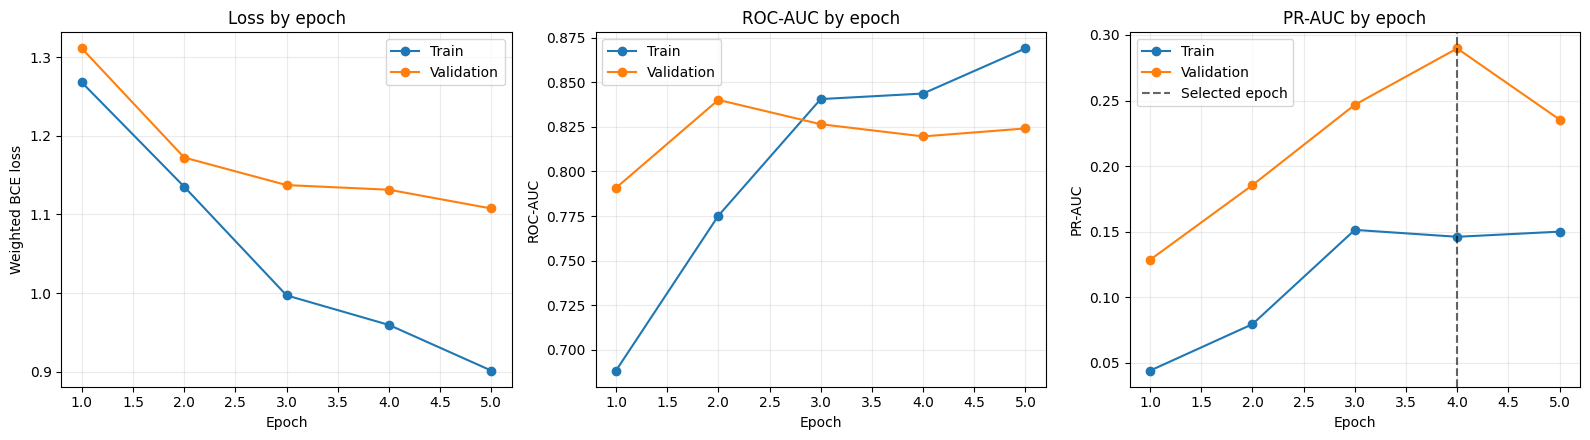

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
axes[0].plot(history_df["epoch"], history_df["validation_loss"], marker="o", label="Validation")
axes[0].set_title("Loss by epoch")
axes[0].set_ylabel("Weighted BCE loss")

axes[1].plot(history_df["epoch"], history_df["train_roc_auc"], marker="o", label="Train")
axes[1].plot(history_df["epoch"], history_df["validation_roc_auc"], marker="o", label="Validation")
axes[1].set_title("ROC-AUC by epoch")
axes[1].set_ylabel("ROC-AUC")

axes[2].plot(history_df["epoch"], history_df["train_pr_auc"], marker="o", label="Train")
axes[2].plot(history_df["epoch"], history_df["validation_pr_auc"], marker="o", label="Validation")
axes[2].axvline(best_epoch, color="black", linestyle="--", alpha=0.6, label="Selected epoch")
axes[2].set_title("PR-AUC by epoch")
axes[2].set_ylabel("PR-AUC")

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.grid(alpha=0.25)
    axis.legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "efficientnet_learning_curves.png", dpi=200, bbox_inches="tight")
plt.show()


# Reload the best checkpoint

In [ ]:
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=True,
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded epoch:", checkpoint["epoch"])
print("Stored validation ROC-AUC:", checkpoint["validation_roc_auc"])
print("Stored validation PR-AUC:", checkpoint["validation_pr_auc"])


Loaded epoch: 4
Stored validation ROC-AUC: 0.8196415131157138
Stored validation PR-AUC: 0.2897284321776946


#Choose a high-sensitivity threshold using validation data

In [ ]:
TARGET_SENSITIVITY = 0.90

validation_targets, validation_probabilities = predict(model, val_loader)
validation_fpr, validation_tpr, validation_thresholds = roc_curve(
    validation_targets, validation_probabilities
)

eligible_indices = np.flatnonzero(validation_tpr >= TARGET_SENSITIVITY)
assert len(eligible_indices) > 0, "No validation threshold reached the target sensitivity"

# First minimise false-positive rate. If tied, use the highest threshold.
best_fpr = validation_fpr[eligible_indices].min()
tied_indices = eligible_indices[
    validation_fpr[eligible_indices] == best_fpr
]
selected_index = tied_indices[
    np.argmax(validation_thresholds[tied_indices])
]

decision_threshold = float(validation_thresholds[selected_index])
achieved_validation_sensitivity = float(validation_tpr[selected_index])
achieved_validation_specificity = float(1 - validation_fpr[selected_index])

print("Selected threshold:", round(decision_threshold, 6))
print("Validation sensitivity:", round(achieved_validation_sensitivity, 3))
print("Validation specificity:", round(achieved_validation_specificity, 3))


Selected threshold: 0.362618
Validation sensitivity: 0.931
Validation specificity: 0.408


# Final test evaluation

In [ ]:
test_targets, test_probabilities = predict(model, test_loader)
test_predictions = (test_probabilities >= decision_threshold).astype(int)

tn, fp, fn, tp = confusion_matrix(
    test_targets, test_predictions, labels=[0, 1]
).ravel()

def safe_divide(numerator, denominator):
    return numerator / denominator if denominator else np.nan


test_metrics = {
    "selected_epoch": int(checkpoint["epoch"]),
    "decision_threshold": float(decision_threshold),
    "roc_auc": float(roc_auc_score(test_targets, test_probabilities)),
    "pr_auc": float(average_precision_score(test_targets, test_probabilities)),
    "accuracy": float((test_predictions == test_targets).mean()),
    "sensitivity_recall": float(safe_divide(tp, tp + fn)),
    "specificity": float(safe_divide(tn, tn + fp)),
    "precision": float(safe_divide(tp, tp + fp)),
    "negative_predictive_value": float(safe_divide(tn, tn + fn)),
    "false_negatives": int(fn),
    "false_positives": int(fp),
    "true_positives": int(tp),
    "true_negatives": int(tn),
}

display(
    pd.DataFrame([test_metrics]).T.rename(columns={0: "value"})
)

with open(OUTPUT_DIR / "efficientnet_test_metrics.json", "w") as file:
    json.dump(test_metrics, file, indent=2)

prediction_output = test_df[["image_name", "target"]].copy()
prediction_output["melanoma_probability"] = test_probabilities
prediction_output["predicted_class"] = test_predictions
prediction_output.to_csv(
    OUTPUT_DIR / "efficientnet_test_predictions.csv", index=False
)


,value
selected_epoch,4.000000
decision_threshold,0.362618
roc_auc,0.858902
pr_auc,0.103641
accuracy,0.472837
sensitivity_recall,0.967742
specificity,0.464997
precision,0.027855
negative_predictive_value,0.998902
false_negatives,1.000000


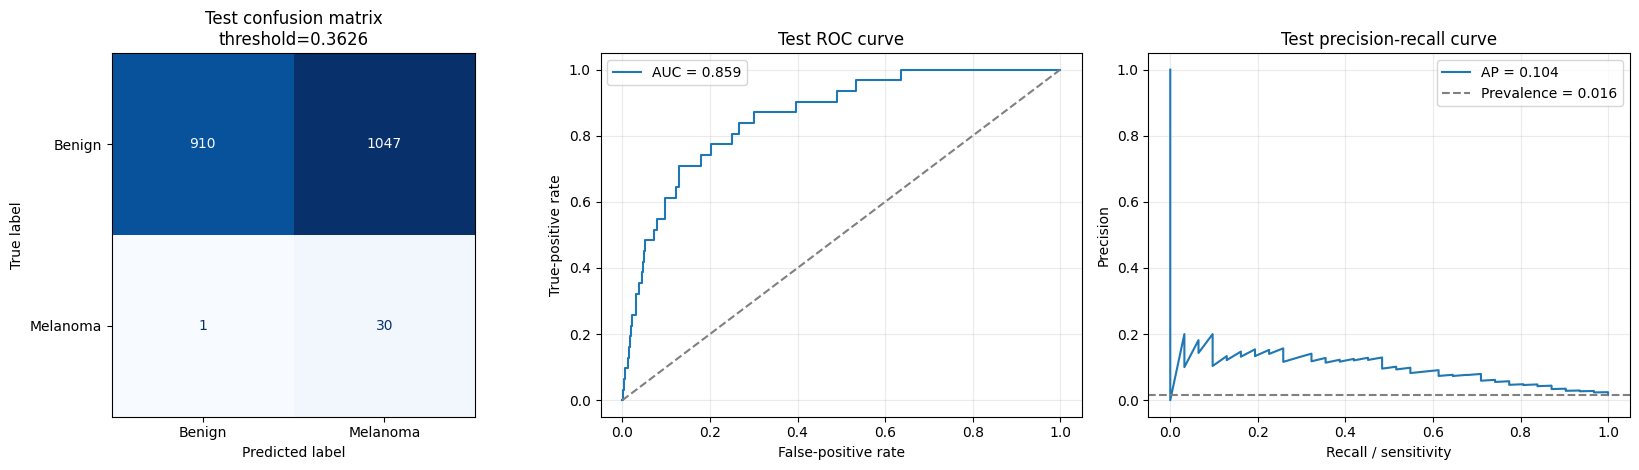

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Benign", "Melanoma"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Test confusion matrix\nthreshold={decision_threshold:.4f}")

test_fpr, test_tpr, _ = roc_curve(test_targets, test_probabilities)
axes[1].plot(test_fpr, test_tpr, label=f"AUC = {test_metrics['roc_auc']:.3f}")
axes[1].plot([0, 1], [0, 1], "--", color="grey")
axes[1].set_xlabel("False-positive rate")
axes[1].set_ylabel("True-positive rate")
axes[1].set_title("Test ROC curve")
axes[1].legend()
axes[1].grid(alpha=0.25)

test_precision, test_recall, _ = precision_recall_curve(
    test_targets, test_probabilities
)
prevalence = test_targets.mean()
axes[2].plot(test_recall, test_precision, label=f"AP = {test_metrics['pr_auc']:.3f}")
axes[2].axhline(prevalence, linestyle="--", color="grey", label=f"Prevalence = {prevalence:.3f}")
axes[2].set_xlabel("Recall / sensitivity")
axes[2].set_ylabel("Precision")
axes[2].set_title("Test precision-recall curve")
axes[2].legend()
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "efficientnet_test_evaluation.png", dpi=200, bbox_inches="tight")
plt.show()


EfficientNet-B0 was partially fine-tuned using ImageNet-pretrained weights, strong image augmentation and class-weighted binary cross-entropy. Validation PR-AUC reached its highest value of 0.290 at epoch 4, so this checkpoint was retained for final evaluation. A threshold of 0.363 was selected exclusively from validation data to prioritise melanoma sensitivity. On the test set, the model achieved a ROC-AUC of 0.859 and PR-AUC of 0.104. It correctly detected 30 of 31 melanomas, producing a sensitivity of 96.8% and only one false negative. However, specificity was 46.5%, with 1,047 benign lesions incorrectly flagged. Therefore, the model successfully prioritised the reduction of missed melanomas but did so at the cost of a high false-positive burden.